### Pilot study, simplified model
June 1, 2026

In [157]:
# === IMPORTS ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

from astropy import units as u
from astropy import constants as const
from pathlib import Path
from time import time
import seaborn as sns
import pickle as pkl

import mmr_id
import rebound_sims as reb_sims

import warnings
warnings.filterwarnings('ignore')

def plot_prettier(dpi=150, fontsize=11, usetex=False): 
    '''
    Make plots look nicer compared to Matplotlib defaults
    Parameters: 
        dpi - int, "dots per inch" - controls resolution of PNG images that are produced
                by Matplotlib
        fontsize - int, font size to use overall
        usetex - bool, whether to use LaTeX to render fonds of axes labels 
                use False if you don't have LaTeX installed on your system
    '''
    plt.rcParams['figure.dpi']= dpi
    plt.rc("savefig", dpi=dpi)
    plt.rc('font', size=fontsize)
    plt.rc('xtick', direction='in') 
    plt.rc('ytick', direction='in')
    plt.rc('xtick.major', pad=5) 
    plt.rc('xtick.minor', pad=5)
    plt.rc('ytick.major', pad=5) 
    plt.rc('ytick.minor', pad=5)
    plt.rc('lines', dotted_pattern = [2., 2.])
    if usetex:
        plt.rc('text', usetex=usetex)
    else:
        plt.rcParams['mathtext.fontset'] = 'cm'
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

plot_prettier()

# === UNIT CONVERSIONS ===
AU = u.AU.to(u.cm)    
G = 4*np.pi**2 # in yr, AU, Msun
Msun = u.Msun.to(u.g) 
yr = u.yr.to(u.s)    
r_earth = u.earthRad.to(u.AU)
m_earth = u.Mearth.to(u.Msun)
r_sun = u.Rsun.to(u.AU) 

#### Load dataset and get general information
Once simulations have been saved, the following code can be used to look at the evolution of orbital elements and period ratios, as well as checking whether there is resonance in the final configuration.

In [158]:
# Process data for any given dataset
dataset_id = 0

all_outcomes = []
outcome_file = f"../sim_results/dataset{dataset_id}/outcomes.pkl"
with open(outcome_file, "rb") as f:
    sim_outcomes = pkl.load(f)
all_outcomes += sim_outcomes
    
n_sims = len(all_outcomes)

columns = [
    "sim_id",
    "m_vals",
    "r_vals",
    "m_star",
    "r_star",
]

outcome_df = pd.DataFrame(all_outcomes, columns=columns)
outcome_df = outcome_df.sort_values(by='sim_id') 

#### Investigate a specific simulation run & plot it

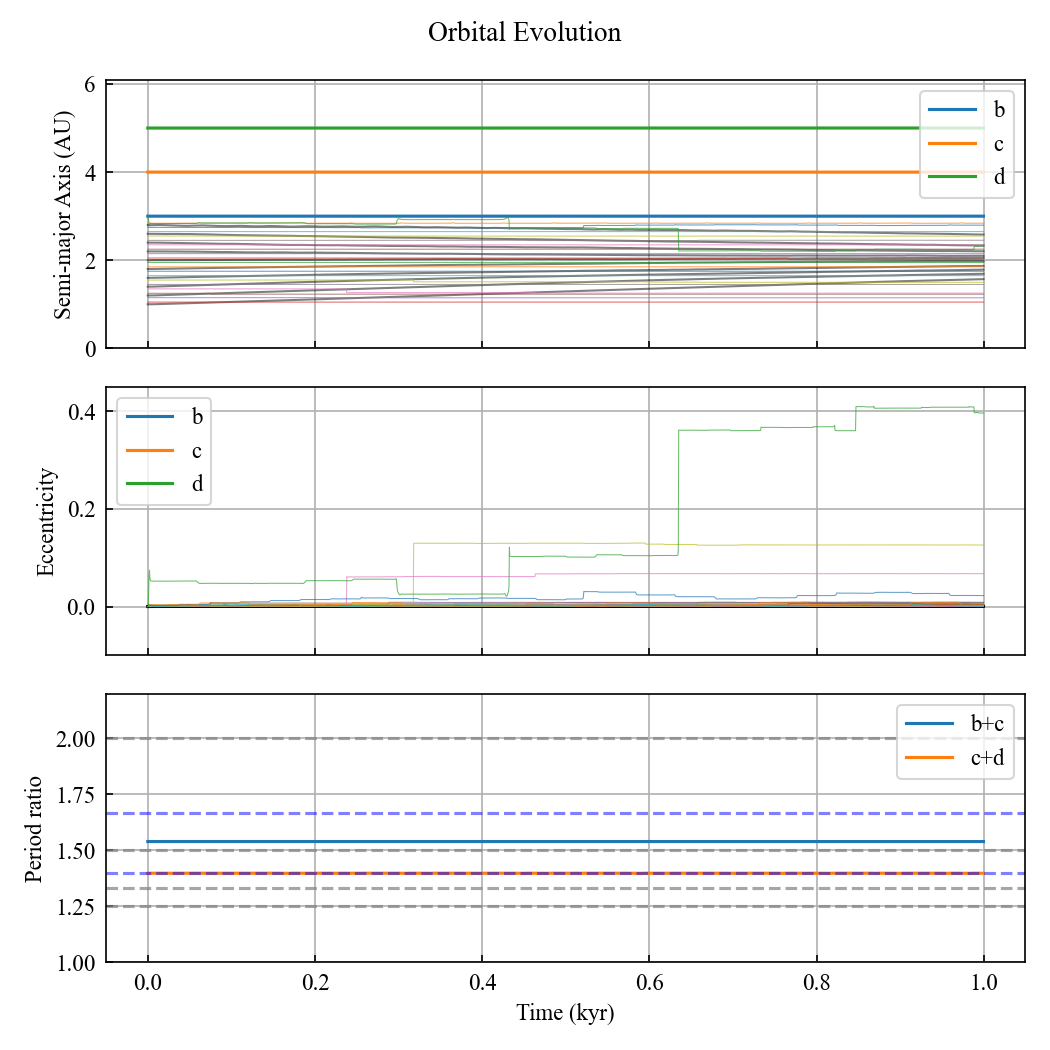

In [ ]:
sim_id = 0
base_dir = Path.cwd()
file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"

row = outcome_df.loc[outcome_df["sim_id"] == sim_id].iloc[0]

saved_sim = reb_sims.load_simulation_run(file_path)
sim_data = saved_sim[0]
m_star = saved_sim[1]['m_star'] 
rock_names = saved_sim[1]['rock_names']

rocks = {p: sim_data[p] for p in rock_names}

num_pl, num_em, num_ptsml = saved_sim[1]['num_pl'], saved_sim[1]['num_em'], saved_sim[1]['num_ptsml']

# Example usage
# print(saved_sim[1]['m_star'])
# print(planets['b'][:5])
# print(planets['b']['a'][:5])
# print(planets['b'].attrs["planet_name"])

# === PLOTTING ===

def plot_system(sim_data, num_pl, num_em, num_ptsml, t_units='kyr'):
    '''
    Takes dataframes for planets and plots a, e, and P ratios over time.
    '''
    times = sim_data[0]['b']['time']
    planet_names = list(sim_data[0].keys())
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)
    fig.set_figwidth(7)
    fig.set_figheight(7)

    for i in range(num_pl):
        # could also try plotting log
        name = rock_names[i]
        
        if t_units == 'kyr':
            ax1.plot(times/1000, sim_data[0][name]["a"], label=name)
            ax2.plot(times/1000, sim_data[0][name]["e"], label=name)
            plt.xlabel("Time (kyr)")
    
        if i != num_pl-1:
            ax3.plot(times/1000, sim_data[0][name]["P_ratio"], label=f"{name}+{rock_names[i+1]}")
    
    for i in range(num_em):
        # could also try plotting log
        name = rock_names[i+num_pl]
        
        if t_units == 'kyr':
            ax1.plot(times/1000, sim_data[0][name]["a"], c='k', alpha=0.5, lw=1)
            ax2.plot(times/1000, sim_data[0][name]["e"], c='k', alpha=0.5, lw=1)
    
    for i in range(num_ptsml):
        # could also try plotting log
        name = rock_names[i+num_pl+num_em]
        
        if t_units == 'kyr':
            ax1.plot(times/1000, sim_data[0][name]["a"], alpha=0.7, lw=0.5)
            ax2.plot(times/1000, sim_data[0][name]["e"], alpha=0.7, lw=0.5)
    
            
    ax1.set_ylabel("Semi-major Axis (AU)")
    ax2.set_ylabel("Eccentricity")
    ax3.set_ylabel("Period ratio")
    
    ax1.set_ylim(0,6.5)
    ax2.set_ylim(-0.05,0.15)
    ax3.set_ylim(1,2.2)
    
    # Plot ide location & width
    try:
        ax1.axhline(sim_data[1]["ide_position"], color='gray', ls='--', alpha=0.7)
        ax1.axhline(sim_data[1]["ide_position"] - sim_data[1]["ide_width"], color='gray', ls='--', alpha=0.1)
        ax1.axhline(sim_data[1]["ide_position"] + sim_data[1]["ide_width"], color='gray', ls='--', alpha=0.1)
    except:
        pass

    ax1.legend(); ax2.legend(); ax3.legend()
    ax1.grid(True); ax2.grid(True); ax3.grid(True)
    
    # Add horizontal lines for resonances
    resonances_1 = [2/1, 3/2, 4/3, 5/4]
    resonances_2 = [3/1, 5/3, 7/5]
    resonances_3 = [4/1, 5/2, 7/4, 8/5]
    for r in resonances_1:
        ax3.axhline(r, color='gray', ls='--', alpha=0.7)
    for r in resonances_2:
        ax3.axhline(r, color='blue', ls='--', alpha=0.5)
    # for r in resonances_3:
    #     ax3.axhline(r, color='red', ls='--', alpha=0.5)

    fig.subplots_adjust(hspace=0)

    plt.suptitle("Orbital Evolution")
    plt.tight_layout(); plt.show()
    
%matplotlib widget
plot_system(saved_sim, num_pl, num_em, num_ptsml)

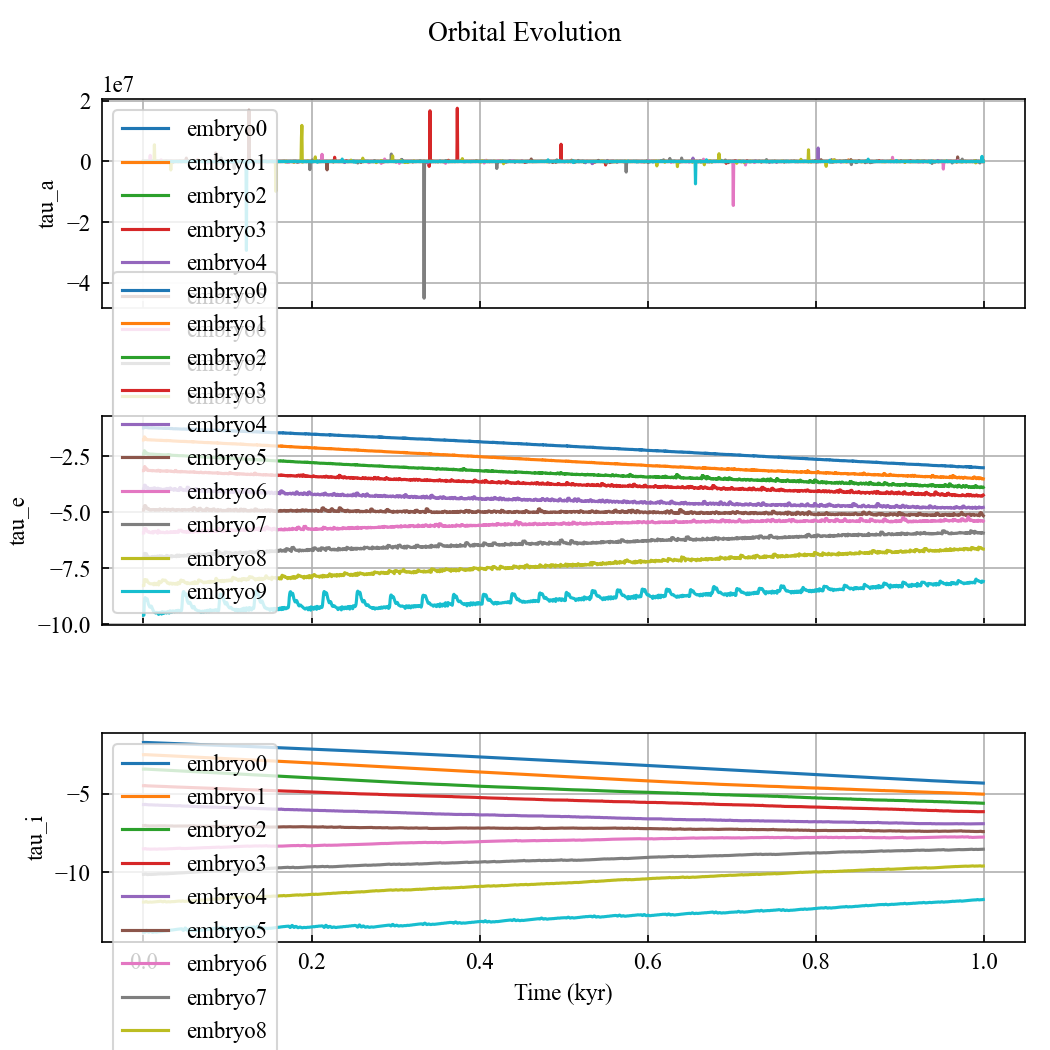

In [160]:
def plot_taus(sim_data, num_pl, num_em, num_ptsml, t_units='kyr'):
    '''
    Takes dataframes for planets and plots a, e, and P ratios over time.
    '''
    times = sim_data[0]['b']['time']
    planet_names = list(sim_data[0].keys())
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)
    fig.set_figwidth(7)
    fig.set_figheight(7)

    for i in range(num_em):
        # could also try plotting log
        name = rock_names[i+num_pl]
        
        if t_units == 'kyr':
            ax1.plot(times/1000, sim_data[0][name]["tau_a"], label=name)
            ax2.plot(times/1000, sim_data[0][name]["tau_e"], label=name)
            ax3.plot(times/1000, sim_data[0][name]["tau_i"], label=name)
            plt.xlabel("Time (kyr)")
            
    ax1.set_ylabel("tau_a")
    ax2.set_ylabel("tau_e")
    ax3.set_ylabel("tau_i")
    
    # ax1.set_ylim(0,5)
    # ax2.set_ylim(-0.1,0.45)
    # ax3.set_ylim(1,2.2)
    
    ax1.legend(); ax2.legend(); ax3.legend()
    ax1.grid(True); ax2.grid(True); ax3.grid(True)

    fig.subplots_adjust(hspace=0)

    plt.suptitle("Orbital Evolution")
    plt.tight_layout(); plt.show()
    
plot_taus(saved_sim, num_pl, num_em, num_ptsml)

True period ratio: 1.5395
p, q: 3, 2
Libration amplitude: 41.2 deg


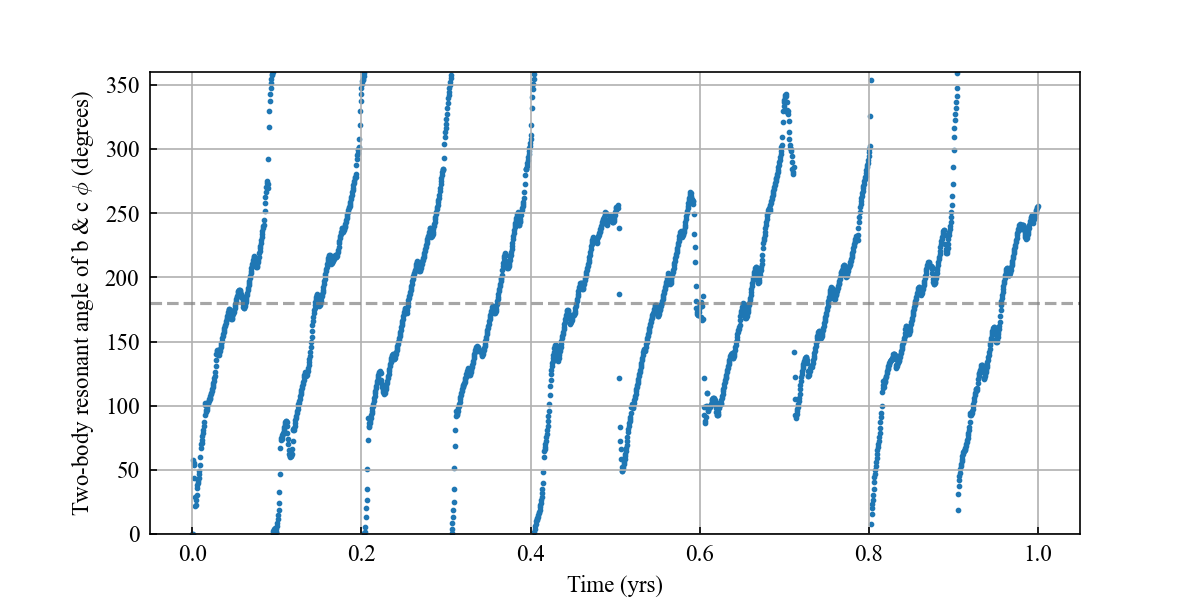

In [161]:
mmr_id.plot_libration(m_star, rocks['b'], rocks['c'])

In [162]:
import rebound
sim = rebound.Simulation()

# Add a star with a string hash
sim.add(m=1.0, hash="sun")

# Add a planet with a string hash
sim.add(m=0.001, a=1.0, hash="earth")


In [163]:
print('sun' in sim.particles)
name = 'embryo12'
print('embryo' in name)

True
True


In [164]:
# Access physical parameters using the hash string
print(sim.particles["sun"].m)

# Remove the particle safely using its hash string
sim.remove(hash="sun")

1.0
